In [1]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import random
import copy

SEARCH_BEST_ESN_MODEL = False
CMA_ES_SEARCH_BEST_ESN_MODEL = False

In [2]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [3]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 2) 
        if len(parts) < 2: continue
        
        terrain, sensor = f"{parts[0]}_{parts[1]}", parts[2]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 6 terrains from walking_terrain_datasets.npz


In [4]:
print(dataset.keys())
print(dataset['solid_ground'].keys())

dict_keys(['solid_ground', 'soft_ground', 'slippery_ground', 'rough_ground', 'muddy_ground', 'water_surface'])
dict_keys(['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'joint_commands', 'joint_angle_fb', 'joint_torque_fb', 'joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'joint_velocity_fb'])


In [5]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot Dataset

In [6]:
def plot_all_individual_cycles(cycle_results, sensor_list, leg_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
        'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[leg_idx] if is_joint else name_legs[leg_idx]
    except (NameError, IndexError):
        feature_name = f"Index {leg_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, leg_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
# plot_all_individual_cycles(dataset, sensors_to_plot, leg_idx=2)

In [7]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {
        'solid_ground': "#000000", 'rough_ground': '#e74c3c', 'water_surface': '#3498db', 
        'soft_ground': '#f1c40f', 'muddy_ground': "#772222", 'slippery_ground': '#9b59b6'
    }
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()
    
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
# plot_all_sensors_comparison(
#     dataset, 
#     sensors_to_plot, 
#     feature_index=0, 
#     feature_name=f"Leg {name_legs[0]}"
# )

# Train Process

## Prepare Dataset

In [8]:

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

def split_and_roll_gait_dataset(dataset, train_ratio=0.8, num_rolls=3, augment_test=True, seed=42):
    """
    Splits the dataset and safely applies 'rolling' augmentation to prevent data leakage.
    
    Args:
        dataset: The nested dictionary containing terrain -> sensor -> cycles.
        train_ratio: Percentage of data to use for training.
        num_rolls: How many additional phase-shifted cycles to generate per original cycle. 
                   (e.g., num_rolls=3 creates shifts at 25%, 50%, and 75% of the cycle length)
        augment_test: If True, applies rolling to the test set as well. Usually kept False.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # Initialize dictionaries for this terrain
        train_set[terrain] = {s: [] for s in dataset[terrain].keys()}
        test_set[terrain]  = {s: [] for s in dataset[terrain].keys()}
        
        # 1. FIND THE MINIMUM CYCLE COUNT (Synchronization Check)
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        sensors = list(dataset[terrain].keys())
        
        # 2. SPLIT INDICES FIRST (To prevent data leakage)
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        # 3. HELPER FUNCTION TO ROLL DATA
        def extract_and_roll(target_dict, index_list, apply_rolling):
            for i in index_list:
                # Find the length of this specific gait cycle (assuming all sensors share the same length for cycle 'i')
                cycle_len = len(dataset[terrain][sensors[0]][i])
                
                # Calculate the exact array indices to shift by.
                # If num_rolls=3, shifts = [0, 25%, 50%, 75% of cycle length]
                if apply_rolling:
                    shifts = [int(cycle_len * (j / (num_rolls + 1))) for j in range(num_rolls + 1)]
                else:
                    shifts = [0] # Only keep the original, unshifted cycle
                
                # Apply the shifts to every sensor so they stay perfectly synchronized
                for shift in shifts:
                    for sensor in sensors:
                        cycle_data = dataset[terrain][sensor][i]
                        
                        # Apply Left-Shift Phase Rolling
                        if isinstance(cycle_data, list):
                            rolled_cycle = cycle_data[shift:] + cycle_data[:shift]
                        else:
                            # Fallback just in case your data is stored as Numpy arrays
                            rolled_cycle = np.roll(cycle_data, -shift, axis=0) 
                            
                        target_dict[sensor].append(copy.deepcopy(rolled_cycle))

        # 4. EXTRACT AND AUGMENT
        # Augment the training set
        extract_and_roll(train_set[terrain], train_indices, apply_rolling=True)
        
        # Extract the testing set (Un-augmented by default)
        extract_and_roll(test_set[terrain], test_indices, apply_rolling=augment_test)

        # Print detailed diagnostic readout
        train_count = len(train_set[terrain][sensors[0]])
        test_count = len(test_set[terrain][sensors[0]])
        
        print(f"Terrain {terrain.upper()}:")
        print(f" -> Original unique cycles: {min_cycles}")
        print(f" -> TRAIN set grew to {train_count} cycles (Augmented {num_rolls}x)")
        print(f" -> TEST set contains {test_count} cycles (Original only)\n")

    return train_set, test_set

# --- Execution ---
# This will split the data 80/20, and then multiply the size of the training set 
# by generating 3 additional phase-shifted variations of every single training cycle.
# train_data, test_data = split_and_roll_gait_dataset(dataset, train_ratio=0.8, num_rolls=10, seed=42)

train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

Terrain SOLID_GROUND: Used 569 synchronized cycles. (170 train, 399 test)
Terrain SOFT_GROUND: Used 569 synchronized cycles. (170 train, 399 test)
Terrain SLIPPERY_GROUND: Used 569 synchronized cycles. (170 train, 399 test)
Terrain ROUGH_GROUND: Used 569 synchronized cycles. (170 train, 399 test)
Terrain MUDDY_GROUND: Used 532 synchronized cycles. (159 train, 373 test)
Terrain WATER_SURFACE: Used 569 synchronized cycles. (170 train, 399 test)


In [9]:
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
# plot_all_individual_cycles(train_data, sensors_to_plot, leg_idx=2)

In [10]:
def flatten_datasets(dataset_dict, terrain_to_id_map, sensor_order):
	"""
	Converts the nested dictionary into flat X and y lists for the ESN.
	
	dataset_dict: The output from your split_dataset function.
	terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
	sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
	"""
	X_formatted = []
	y_formatted = []
	
	for terrain, sensors_data in dataset_dict.items():
		if terrain not in terrain_to_id_map:
			continue # Skip terrains we aren't training on
			
		label = terrain_to_id_map[terrain]
		
		# Get the number of cycles for this terrain (they are synchronized)
		n_cycles = len(sensors_data[sensor_order[0]])
		
		for i in range(n_cycles):
			# For cycle 'i', gather data from all 16 joints (K, D, tau)
			cycle_columns = []
			for sensor_name in sensor_order:
				# Ensure it's a numpy array
				sensor_array = np.array(sensors_data[sensor_name][i])
				
				# If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
				if len(sensor_array.shape) == 1:
					sensor_array = sensor_array.reshape(-1, 1)
					
				cycle_columns.append(sensor_array)
			
			# Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
			full_gait_matrix = np.hstack(cycle_columns)
			
			X_formatted.append(full_gait_matrix)
			y_formatted.append(label)
			
	return X_formatted, np.array(y_formatted)

In [11]:

def simulate_sensor_noise_ptp(X_test, noise_level=0.10, seed=42):
    """
    Simulates noise scaled to the Peak-to-Peak (Full-Scale) range of the sensor.
    	
    Yes, absolutely! In fact, scaling noise to the Peak-to-Peak (PTP) value or the Maximum Absolute Magnitude 
    is exactly how hardware engineers typically define the "Full-Scale Signal-to-Noise Ratio (SNR)"
    for physical sensors like load cells and ADCs.
    
    """
    np.random.seed(seed)
    X_noisy = []
    
    for cycle in X_test:
        noisy_cycle = cycle.copy()
        
        # Calculate Peak-to-Peak (Max - Min) across time for each feature
        # This is the "Full-Scale Range" of the sensor for this specific step
        
        feature_scales = np.ptp(noisy_cycle, axis=0)
        # feature_scales = np.max(np.abs(noisy_cycle), axis=0)
        
        # Fallback for completely flat signals to prevent zero-scaling
        feature_scales[feature_scales == 0] = 1.0
        
        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        
        # Scale the noise by the Peak-to-Peak range
        scaled_noise = standard_normal_noise * (noise_level * feature_scales)
        
        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)
        
    return X_noisy

## Training

In [ ]:
import os
import sys
import numpy as np
import optuna
from optuna.samplers import CmaEsSampler
from models.model_1_esn_rr.env_pred import ESN_RR_Classification

# Suppress Optuna's default print spam to keep your terminal output clean
optuna.logging.set_verbosity(optuna.logging.WARNING)


# ==========================================
# 2. DEFINITIONS & CONFIGURATIONS
# ==========================================
# TERRAIN_LABELS = {
#     'solid_ground'      : 0,
#     'soft_ground'       : 1,
#     'slippery_ground'   : 2,
#     'rough_ground'      : 3,
#     'muddy_ground'      : 4,
#     'water_surface'     : 5
# }

TERRAIN_LABELS = {
    'solid_ground'      : 0,
    'slippery_ground'   : 1,
    'muddy_ground'      : 2,
    'water_surface'     : 3
}

SENSOR_CONFIGURATIONS = [
    # 1
    # ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
    # ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
    # ['joint_torque_fb'],
    # 6
    # ['joint_torque_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['cpg_output', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['cpg_output',  'joint_commands', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    ['cpg_output',  'joint_commands', 'joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
]


CMA_ES_SEARCH_BEST_ESN_MODEL = True
N_TRIALS_PER_CONFIG = 10 

# ==========================================
# 3. MAIN SEARCH LOOP
# ==========================================
if CMA_ES_SEARCH_BEST_ESN_MODEL:
    print(f"Total Sensor Configurations to optimize: {len(SENSOR_CONFIGURATIONS)}\n")
    
    # Ensure the save directory exists
    os.makedirs("trained_models_final", exist_ok=True)

    for config_idx, current_sensor_keys in enumerate(SENSOR_CONFIGURATIONS):
        
        config_name = f"config_{config_idx + 11}"
        
        print("\n" + "#"*60)
        print(f"🚀 STARTING CMA-ES SEARCH [{config_name} / {len(SENSOR_CONFIGURATIONS)}]")
        print(f"📡 Sensors: {current_sensor_keys}")
        print("#"*60)

        # --- Format original clean dataset ---
        X_train_clean, y_train_clean = flatten_datasets(train_data, TERRAIN_LABELS, current_sensor_keys)
        X_test_clean, y_test_clean = flatten_datasets(test_data, TERRAIN_LABELS, current_sensor_keys)
        
        # --- Data Leakage Check ---
        if len(X_test_clean) > 0 and len(X_train_clean) > 0:
            test_sample = X_test_clean[0] 
            leak_found = any(np.array_equal(test_sample, train_sample) for train_sample in X_train_clean)
            if leak_found:
                print("🚨 WARNING: DATA LEAKAGE DETECTED! Test data is inside training data!")
            else:
                print("✅ Data split is clean! No exact duplicates found.")

        # ==========================================
        # ⚡ SPEED OPTIMIZATION: PRE-GENERATE NOISE
        # ==========================================
        print("🧬 Generating Augmented Training and Evaluation Sets...")
        
        # 1. Create a noisy training set (e.g., 10% noise)
        X_train_noisy = simulate_sensor_noise_ptp(X_train_clean, noise_level=0.10, seed=42)
        
        # Combine Clean + Noisy for robust training
        X_train_aug = list(X_train_clean) + list(X_train_noisy)
        y_train_aug = np.concatenate([np.array(y_train_clean), np.array(y_train_clean)])
        
        # 2. Create a harsher evaluation set (e.g., 15% noise) to force the optimizer 
        # to prioritize hyperparameter stability over pure memorization.
        X_test_noisy = simulate_sensor_noise_ptp(X_test_clean, noise_level=0.15, seed=99)
        
        X_test_eval = list(X_test_clean) + list(X_test_noisy)
        y_test_eval = np.concatenate([np.array(y_test_clean), np.array(y_test_clean)])
        
        print(f"Total Augmented Training Cycles: {len(X_train_aug)}")
        print(f"Total Robust Evaluation Cycles: {len(X_test_eval)}")
        print(f"Input Matrix Shape: {X_train_aug[0].shape}\n") 

        # ==========================================
        # 4. OPTUNA CMA-ES OBJECTIVE FUNCTION
        # ==========================================
        def objective(trial):
            n_res = trial.suggest_int('n_reservoir', 500, 5000)
            leak_rate = trial.suggest_float('leak_rate', 0.1, 0.9)
            spectral_radius = trial.suggest_float('spectral_radius', 0.7, 1.25)
            lambda_reg = trial.suggest_float('lambda_reg', 1e-4, 1.0, log=True)
            
            model = ESN_RR_Classification(
                n_reservoir=n_res, 
                leak_rate=leak_rate, 
                spectral_radius=spectral_radius, 
                lambda_reg=lambda_reg,
                ignore_time_column=True,
                output_steps='mean',
                random_state=42
            )
            
            try:
                sys.stdout = open(os.devnull, 'w')
                # 🚨 Train strictly on the AUGMENTED dataset
                model.fit(X_train_aug, y_train_aug)
                sys.stdout = sys.__stdout__
                
                correct = 0
                for j in range(len(X_test_eval)):
                    # 🚨 Evaluate strictly on the NOISY evaluation set
                    predicted_class, _ = model.predict(X_test_eval[j])
                    if predicted_class == y_test_eval[j]:
                        correct += 1
                        
                accuracy = (correct / len(X_test_eval)) * 100.0
                
            except Exception as e:
                sys.stdout = sys.__stdout__
                # Return a baseline accuracy (e.g. 10%) instead of 0.0 to help gradients
                return 10.0 
                
            return accuracy

        # ==========================================
        # 5. EXECUTE SEARCH & SAVE BEST MODEL
        # ==========================================
        # Added IPOP restart strategy so it doesn't get stuck in local optima
        sampler = CmaEsSampler(seed=42, restart_strategy="ipop", inc_popsize=2)
        study = optuna.create_study(direction="maximize", sampler=sampler)
        
        print(f"Running CMA-ES for {N_TRIALS_PER_CONFIG} generations...")
        study.optimize(objective, n_trials=N_TRIALS_PER_CONFIG, show_progress_bar=True)
        
        best_params = study.best_params
        best_accuracy = study.best_value

        print("\n" + "="*50)
        print(f"🏆 BEST MODEL FOUND FOR: {config_name.upper()}")
        print(f"Robust Accuracy: {best_accuracy:.2f}%")
        print("Parameters:")
        for k, v in best_params.items():
            if k == 'n_reservoir':
                print(f" - {k}: {v}")
            else:
                print(f" - {k}: {v:.5f}")
        print("="*50 + "\n")

        # --- Train Final Model with Best Params and Save ---
        print("Training final robust model with optimal parameters to save to disk...")
        final_model = ESN_RR_Classification(
            n_reservoir=best_params['n_reservoir'], 
            leak_rate=best_params['leak_rate'], 
            spectral_radius=best_params['spectral_radius'], 
            lambda_reg=best_params['lambda_reg'],
            ignore_time_column=True,
            output_steps='mean',
            random_state=42
        )
        
        # Train final saved model on the full augmented suite
        final_model.fit(X_train_aug, y_train_aug)
        
        filename = f"trained_models_final/model_1_esn_{config_name}_w_cma_es.pt"
        final_model.save_model(filename)
            
print("\n✅ ALL CONFIGURATIONS TESTED AND SAVED!")

Total Sensor Configurations to optimize: 1


############################################################
🚀 STARTING CMA-ES SEARCH [config_11 / 1]
📡 Sensors: ['cpg_output', 'joint_commands', 'joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb']
############################################################
✅ Data split is clean! No exact duplicates found.
🧬 Generating Augmented Training and Evaluation Sets...
Total Augmented Training Cycles: 1338
Total Robust Evaluation Cycles: 3140
Input Matrix Shape: (100, 124)

Running CMA-ES for 10 generations...


/home/runj/.local/lib/python3.10/site-packages/optuna/samplers/_cmaes.py:293: FutureWarning: `restart_strategy` has been deprecated in v4.4.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.4.0. From v4.4.0 onward, `restart_strategy` automatically falls back to `None`. `restart_strategy` will be supported in OptunaHub.
  optuna_warn(


  0%|          | 0/10 [00:00<?, ?it/s]

# Test

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. LOAD THE MODEL
# ==========================================
print("Booting up ESN Controller...")

SENSOR_CONFIGURATIONS = [
    # 1
    # ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb'],
    # ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward'],
    # ['joint_torque_fb'],
    # 6
    # ['joint_torque_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['cpg_output', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    # ['cpg_output',  'joint_commands', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
    ['cpg_output',  'joint_commands', 'joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
]


# Initialize an empty model
model = ESN_RR_Classification()
# Load the weights from the file generated by your Grid Search

# MODEL_FILENAME = "trained_models_final/model_1_esn_config_8_w_cma_es.pt"	
MODEL_FILENAME = "trained_models_final/model_1_esn_config_11_w_cma_es.pt"	

model.load_model(MODEL_FILENAME)

# ==========================================
# 2. DEFINE YOUR MAPPINGS
# ==========================================
# Extract the 6 terrain classes dynamically from the loaded dataset
terrains = list(dataset.keys())

# Create mappings to turn the integer back into a readable string and vice versa
ID_TO_TERRAIN = {i: name for i, name in enumerate(TERRAIN_LABELS)}
TERRAIN_LABELS = {name: i for i, name in enumerate(TERRAIN_LABELS)}

X_train, y_train = flatten_datasets(train_data, TERRAIN_LABELS, SENSOR_CONFIGURATIONS[0])
X_test, y_test = flatten_datasets(test_data, TERRAIN_LABELS, SENSOR_CONFIGURATIONS[0])
print(np.shape(X_test))
# ==========================================
# 3. EVALUATE TEST SET & PLOT CONFUSION MATRIX
# ==========================================
print("\nEvaluating on unseen Test Set...")
y_pred = []

# Collect all predictions for isolated gait cycles
for i in range(len(X_test)):
    predicted_class, confidence = model.predict(X_test[i])
    y_pred.append(predicted_class)

y_pred = np.array(y_pred)

# Calculate Accuracy
correct = np.sum(y_pred == y_test)
accuracy = (correct / len(X_test)) * 100
print(f"Test Accuracy: {accuracy:.2f}%")


In [ ]:
ID_TO_TERRAIN

{0: 'solid_ground',
 1: 'slippery_ground',
 2: 'muddy_ground',
 3: 'water_surface'}

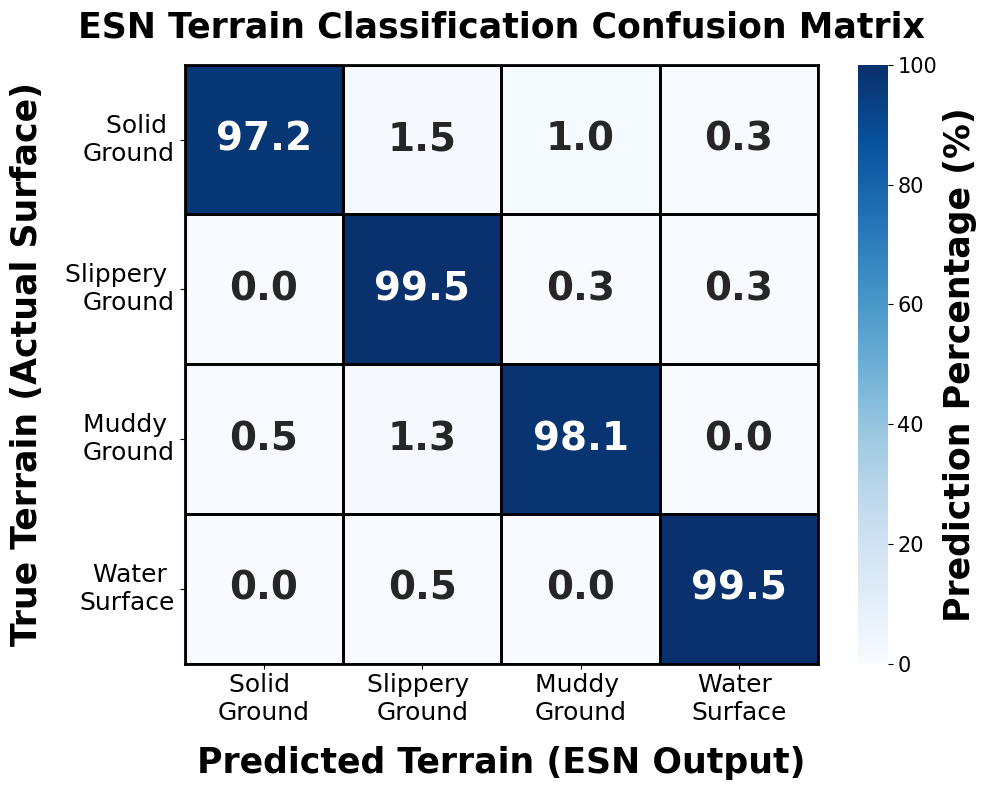

In [ ]:

# Generate Confusion Matrix
# custom_order = [0, 1, 2, 3, 4, 5] 
custom_order = [0, 1, 2, 3] 

# 1. Generate the confusion matrix using your custom order
cm = confusion_matrix(y_test, y_pred, labels=custom_order)

# 2. Generate the formatted names using that same custom order
terrain_names = [ID_TO_TERRAIN[i].replace('_', ' \n').title() for i in custom_order]

# Convert raw counts to percentages (Row-normalized: each actual terrain row sums to 100%)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Prevent AttributeError if leak_rate isn't an explicit attribute on the loaded model
leak_rate_str = getattr(model, 'leak_rate', 'N/A')

# Create Figure and Axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the Heatmap using your custom theme
sns.heatmap(
    cm_perc, 
    annot=True,          
    fmt=".1f",                           # Format as a float with 2 decimal places (e.g., 95.50)
    cmap='Blues',                        # Keeping Blues for confusion matrix
    vmax=100.0,                          # Max percentage is 100
    linewidths=1,        
    linecolor='black',
    annot_kws={"size": 28, "weight": "bold"}, 
    cbar_kws={'label': 'Percentage (%)'},
    xticklabels=terrain_names, 
    yticklabels=terrain_names,
    ax=ax
)

# ==========================================
# COLORBAR FONT SIZE LOGIC
# ==========================================
# Get the colorbar object attached to the heatmap
cbar = ax.collections[0].colorbar

# 1. Change the font size of the colorbar NUMBERS (ticks)
cbar.ax.tick_params(labelsize=15) 

# 2. Change the font size of the colorbar LABEL
cbar.set_label('Prediction Percentage (%)', size=25, weight='bold')

# ==========================================
# SPINES & BORDERS
# ==========================================
for _, spine in ax.spines.items():
    spine.set_visible(True)     # Make sure the frame is turned on
    spine.set_linewidth(2.0)    # Set the outer frame thickness
    spine.set_color('black')    # Set the outer frame color

# ==========================================
# LABELS & TITLES
# ==========================================
title_str = f"ESN Terrain Classification Confusion Matrix" # \nAccuracy: {accuracy:.2f}% | Leak Rate: {leak_rate_str}
ax.set_title(title_str, fontsize=25, fontweight='bold', pad=20)
ax.set_xlabel("Predicted Terrain (ESN Output)", fontsize=25, fontweight='bold', labelpad=15)
ax.set_ylabel("True Terrain (Actual Surface)", fontsize=25, fontweight='bold', labelpad=15)

# Rotate the X-axis labels slightly if the environment names are long
# (Set to 45 if terrain names overlap with rotation=0)
plt.xticks(rotation=0, fontsize=18)
plt.yticks(rotation=0, fontsize=18)

plt.tight_layout()
save_path = "esn_confusion_matrix.png"
plt.savefig(save_path, dpi=300)
plt.show()